In [ ]:
import numpy as np
import glob
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
files_list = glob.glob("/content/wildfire_dataset/*.npz")

class FireDataset(Dataset):
    def __init__(self, files):
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        x = data["x"]
        y = data["y"]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [ ]:
train_files, val_files = train_test_split(files_list, test_size=0.2, random_state=42)

train_dataset = FireDataset(train_files)
val_dataset = FireDataset(val_files)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=19):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up = nn.Upsample(scale_factor=2)

        self.dec1 = nn.Sequential(
            nn.Conv2d(96, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        c1 = self.enc1(x)
        p1 = self.pool(c1)

        c2 = self.enc2(p1)

        u1 = self.up(c2)
        x = torch.cat([u1, c1], dim=1)

        x = self.dec1(x)
        return torch.sigmoid(self.out(x))

In [ ]:
def dice_loss(pred, target):
    smooth = 1.
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / \
           (pred.sum() + target.sum() + smooth)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
bce = nn.BCELoss()

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.unsqueeze(1).to(device)

        pred = model(x)

        loss = 0.5 * bce(pred, y) + 0.5 * dice_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.7037
Epoch 2, Loss: 0.5550
Epoch 3, Loss: 0.5369
Epoch 4, Loss: 0.5250
Epoch 5, Loss: 0.5218
Epoch 6, Loss: 0.5185
Epoch 7, Loss: 0.5142
Epoch 8, Loss: 0.5112
Epoch 9, Loss: 0.5091
Epoch 10, Loss: 0.5088
Epoch 11, Loss: 0.5075
Epoch 12, Loss: 0.5081
Epoch 13, Loss: 0.5066
Epoch 14, Loss: 0.5072
Epoch 15, Loss: 0.5047
Epoch 16, Loss: 0.5036
Epoch 17, Loss: 0.5029
Epoch 18, Loss: 0.5021
Epoch 19, Loss: 0.5042
Epoch 20, Loss: 0.4991
Epoch 21, Loss: 0.5014
Epoch 22, Loss: 0.5009
Epoch 23, Loss: 0.5002
Epoch 24, Loss: 0.4995
Epoch 25, Loss: 0.5006
Epoch 26, Loss: 0.5007
Epoch 27, Loss: 0.5020
Epoch 28, Loss: 0.4971
Epoch 29, Loss: 0.5005
Epoch 30, Loss: 0.5018


In [ ]:
model.eval()
val_loss = 0

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.unsqueeze(1).to(device)

        pred = model(x)
        loss = 0.5 * bce(pred, y) + 0.5 * dice_loss(pred, y)

        val_loss += loss.item()

print("Validation Loss:", val_loss / len(val_loader))

Validation Loss: 0.5179041784543258


Min: 1.937235e-09 Max: 0.068717465


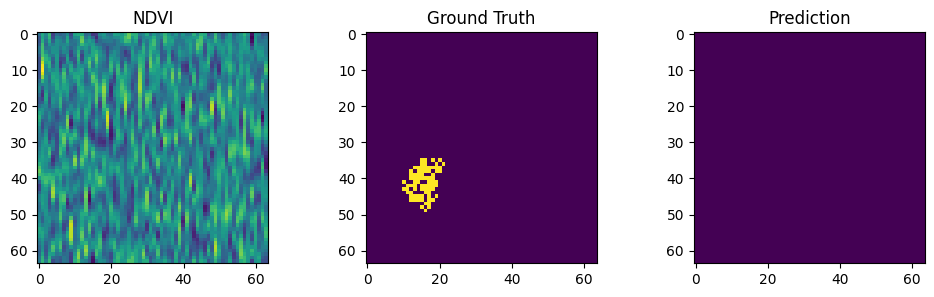

Min: 5.3735727e-09 Max: 0.053097304


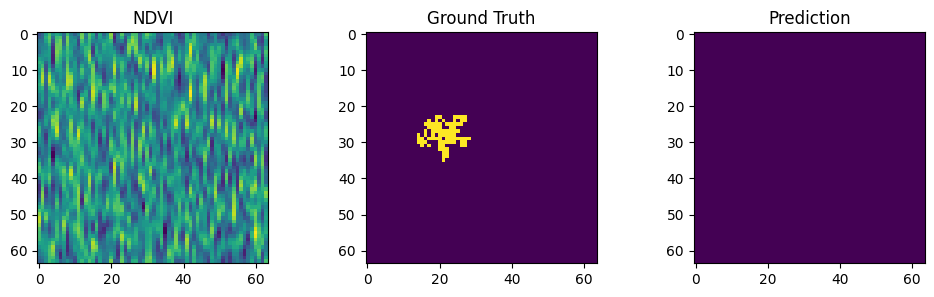

Min: 2.3930833e-09 Max: 0.120319165


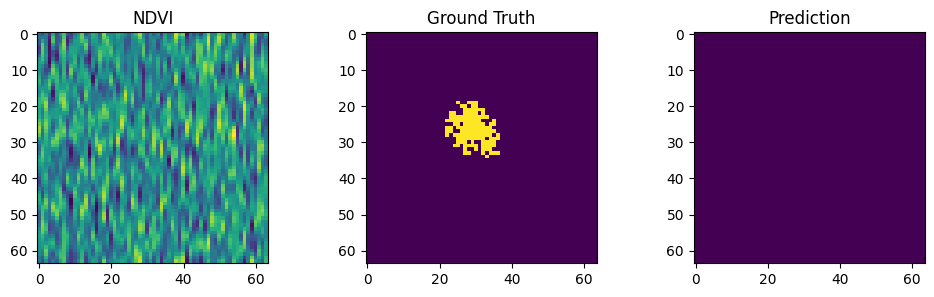

Min: 4.3673214e-11 Max: 0.0038386744


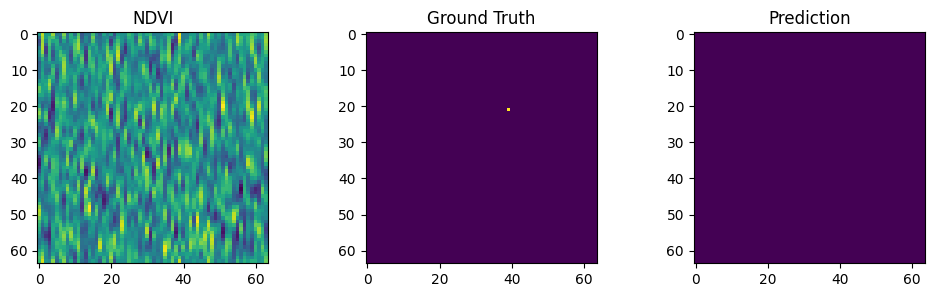

Min: 1.6345039e-10 Max: 0.0050713248


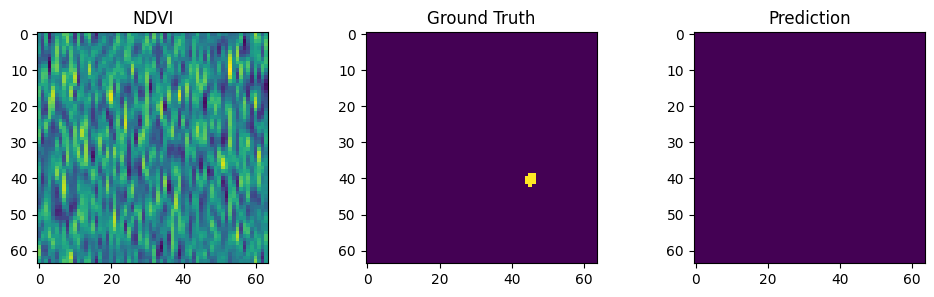

In [ ]:
model.eval()

for i in range(5):
    x, y = val_dataset[i]

    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device))
        pred = pred.cpu().squeeze().numpy()

    print("Min:", pred.min(), "Max:", pred.max())

    plt.figure(figsize=(12,3))

    plt.subplot(1,3,1)
    plt.title("NDVI")
    plt.imshow(x[12])

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(y)

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred > 0.4)  # lowered threshold

    plt.show()

In [ ]:
torch.save(model.state_dict(), "/content/fire_model.pth")